# Customer Churn Prediction using Machine Learning

 ML project using a synthetic telecom customer dataset.

**Goal:** predict whether a customer will churn.

**Models:** Dummy Baseline, Logistic Regression, Random Forest.

**Metrics:** Accuracy, Precision, Recall, F1-score, ROC-AUC.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

In [30]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_raw.csv to customer_churn_raw (4).csv


## 1. Load the raw data

In [31]:
df = pd.read_csv("customer_churn_raw.csv")
print(df.shape)
display(df.head())

(3500, 14)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-00001,Male,0,Yes,No,38,Fiber optic,Yes,Month-to-month,No,Bank transfer (automatic),77.75,2810.88,No
1,CUST-00002,Female,0,Yes,No,6,Fiber optic,No,Two year,No,Mailed check,83.16,541.15,Yes
2,CUST-00003,Female,1,Yes,No,63,Fiber optic,No,Month-to-month,No,Credit card (automatic),63.34,4136.02,No
3,CUST-00004,Male,0,No,No,9,DSL,No,One year,Yes,Credit card (automatic),38.82,509.06,No
4,CUST-00005,Male,0,No,Yes,63,DSL,No,Month-to-month,No,Mailed check,34.53,2144.17,No


## 2. Inspect and understand the data

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        3500 non-null   object 
 1   gender            3500 non-null   object 
 2   SeniorCitizen     3500 non-null   int64  
 3   Partner           3500 non-null   object 
 4   Dependents        3500 non-null   object 
 5   tenure            3500 non-null   int64  
 6   InternetService   3500 non-null   object 
 7   TechSupport       3500 non-null   object 
 8   Contract          3500 non-null   object 
 9   PaperlessBilling  3500 non-null   object 
 10  PaymentMethod     3500 non-null   object 
 11  MonthlyCharges    3500 non-null   float64
 12  TotalCharges      3500 non-null   float64
 13  Churn             3500 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 382.9+ KB


In [33]:
print(df.isna().sum())
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True).mul(100).round(2))

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
InternetService     0
TechSupport         0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
Churn
No     2586
Yes     914
Name: count, dtype: int64

Churn percentage:
Churn
No     73.89
Yes    26.11
Name: proportion, dtype: float64


## 3. Basic EDA

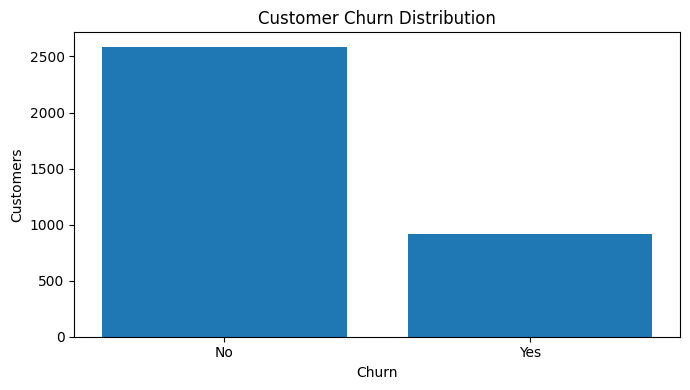

In [34]:
counts = df["Churn"].value_counts().reindex(["No", "Yes"])

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

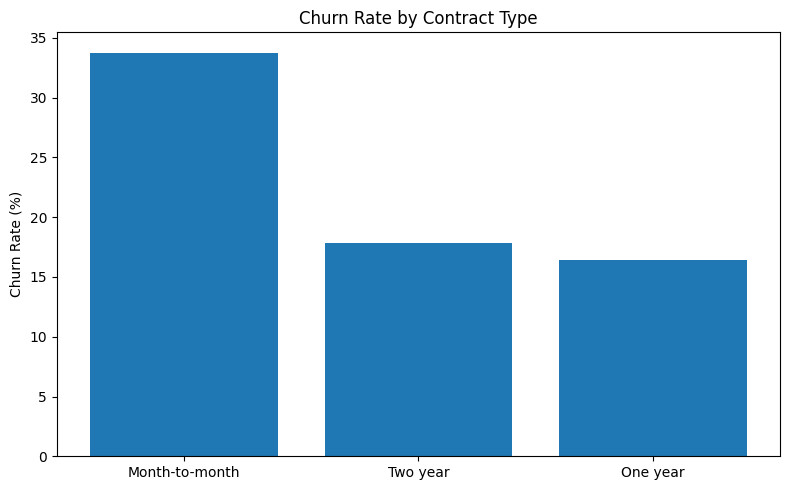

In [35]:
contract_churn = (
    df.assign(ChurnFlag=(df["Churn"] == "Yes").astype(int))
      .groupby("Contract")["ChurnFlag"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(contract_churn.index, contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

## 4. Prepare X and y

In [36]:
X = df.drop(columns=["customerID", "Churn"])
y = (df["Churn"] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2800, 12)
Test: (700, 12)


## 5. Leakage-safe preprocessing

In [37]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## 6. Build the models

In [38]:
dummy_model = DummyClassifier(strategy="most_frequent")

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=350,
        max_depth=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    "Dummy Baseline": dummy_model,
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

## 7. Train and compare

In [39]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Logistic Regression,0.7914,0.6947,0.3607,0.4748,0.8005
2,Random Forest,0.7886,0.7059,0.3279,0.4478,0.7789
0,Dummy Baseline,0.7386,0.0000,0.0000,0.0000,0.5000


## 8. Detailed Logistic Regression evaluation

In [40]:
logistic_model.fit(X_train, y_train)

pred = logistic_model.predict(X_test)
prob = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.81      0.94      0.87       517
       Churn       0.69      0.36      0.47       183

    accuracy                           0.79       700
   macro avg       0.75      0.65      0.67       700
weighted avg       0.78      0.79      0.77       700



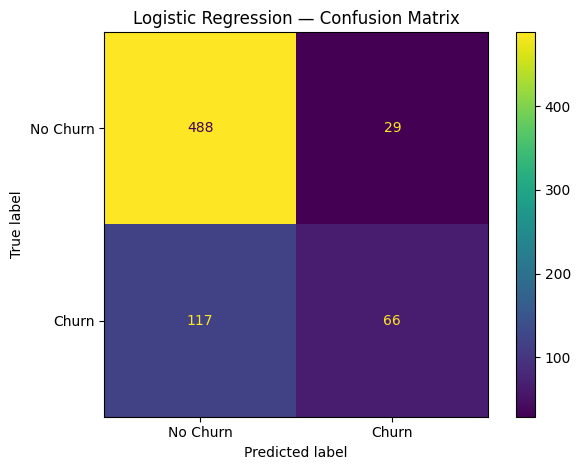

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test, pred,
    display_labels=["No Churn", "Churn"]
)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

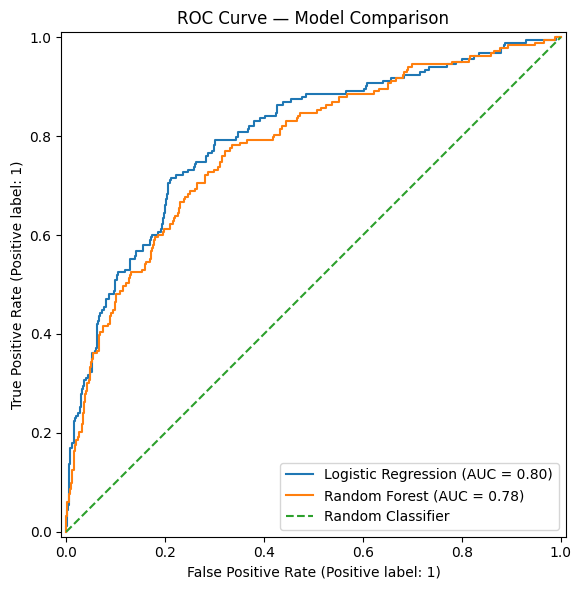

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

for name in ["Logistic Regression", "Random Forest"]:
    model = models[name]
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )
ax.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
ax.set_title("ROC Curve — Model Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Conclusion

Logistic Regression achieved the best overall ranking performance with a ROC-AUC of approximately 0.80, outperforming both Random Forest and the dummy baseline.

However, recall for churned customers was only about 36% at the default classification threshold. This means the model still misses a significant portion of customers who actually churn.

The results show that evaluating a churn model using accuracy alone can be misleading, especially with an imbalanced target. Future improvements could include threshold tuning, class-weight adjustment, cross-validation, and additional feature engineering.